# Data Cleaning & Visualization Project
### Bank Marketing Dataset

This notebook performs data cleaning, processing, and visualization on the
raw `bankmarketing(4).csv` dataset. Scope: data cleaning, visualization,
a simple visual report, and key findings only.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Global plot styling
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

## 2. Load the Dataset

In [2]:
df = pd.read_csv("../data/bankmarketing(4).csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## 3. Initial Inspection

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,41188.0,NaN,NaN,NaN,40.02406,10.42125,17.0,32.0,38.0,47.0,98.0
job,41188,12,admin.,10422,NaN,NaN,NaN,NaN,NaN,NaN,NaN
marital,41188,4,married,24928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education,41188,8,university.degree,12168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
default,41188,3,no,32588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
housing,41188,3,yes,21576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
loan,41188,3,no,33950,NaN,NaN,NaN,NaN,NaN,NaN,NaN
contact,41188,2,cellular,26144,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,41188,10,may,13769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
day_of_week,41188,5,thu,8623,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Data Cleaning

### 4.1 Before-Cleaning Summary

In [5]:
shape_before = df.shape
nulls_before = df.isnull().sum().sum()
dupes_before = df.duplicated().sum()

print("BEFORE CLEANING")
print(f"  Rows x Columns : {shape_before}")
print(f"  Missing values (NaN) : {nulls_before}")
print(f"  Duplicate rows       : {dupes_before}")

BEFORE CLEANING


  Rows x Columns : (41188, 21)
  Missing values (NaN) : 0
  Duplicate rows       : 12


### 4.2 Handling Missing Values

The dataset has no explicit `NaN` values, but several categorical columns
use the string `"unknown"` to represent missing/unrecorded information
(a common pattern in this dataset). We identify and quantify these first.

In [6]:
categorical_cols = df.select_dtypes(include=["object", "str"]).columns.tolist()
unknown_counts = {}
for col in categorical_cols:
    count = (df[col] == "unknown").sum()
    if count > 0:
        unknown_counts[col] = count

unknown_summary = pd.Series(unknown_counts, name="unknown_count").sort_values(ascending=False)
unknown_summary

default      8597
education    1731
housing       990
loan          990
job           330
marital        80
Name: unknown_count, dtype: int64

In [7]:
# Decision: Rather than dropping rows (which would remove up to ~20% of
# records for some columns), we keep "unknown" as its own valid category,
# since it carries information (client declined / not recorded) and
# dropping these rows would bias the dataset. This preserves data integrity.
print("Missing values handled: 'unknown' retained as an explicit category")
print("in categorical columns (no rows dropped for this reason).")

Missing values handled: 'unknown' retained as an explicit category
in categorical columns (no rows dropped for this reason).


### 4.3 Handling Duplicate Records

In [8]:
print(f"Duplicate rows found: {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows after removal: {df.duplicated().sum()}")
print(f"Shape after removing duplicates: {df.shape}")

Duplicate rows found: 12
Duplicate rows after removal: 0
Shape after removing duplicates: (41176, 21)


### 4.4 Handling Outliers (IQR Method)

We apply the Interquartile Range (IQR) method to key numeric columns
(`age`, `campaign`, `duration`, `previous`). Instead of deleting rows
(which would shrink the dataset and lose information), extreme values
are **capped (winsorized)** to the IQR bounds to preserve data integrity.

Note: `pdays` uses a sentinel value of `999` to mean "client was not
previously contacted" — this is not a statistical outlier, so it is
left untouched.

In [9]:
def iqr_bounds(series, k=1.5):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

outlier_cols = ["age", "campaign", "duration", "previous"]
outlier_report = {}

for col in outlier_cols:
    lower, upper = iqr_bounds(df[col])
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        "lower_bound": round(lower, 2),
        "upper_bound": round(upper, 2),
        "outliers_found": int(n_outliers),
    }

pd.DataFrame(outlier_report).T

,lower_bound,upper_bound,outliers_found
age,9.5,69.5,468.0
campaign,-2.0,6.0,2406.0
duration,-223.5,644.5,2963.0
previous,0.0,0.0,5625.0


In [10]:
# Cap (winsorize) outliers to the IQR bounds for each column
for col in outlier_cols:
    lower, upper = iqr_bounds(df[col])
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outliers capped to IQR bounds for:", outlier_cols)

Outliers capped to IQR bounds for: ['age', 'campaign', 'duration', 'previous']


### 4.5 After-Cleaning Summary

In [11]:
shape_after = df.shape
nulls_after = df.isnull().sum().sum()
dupes_after = df.duplicated().sum()

comparison = pd.DataFrame({
    "Before": [shape_before[0], shape_before[1], nulls_before, dupes_before],
    "After":  [shape_after[0], shape_after[1], nulls_after, dupes_after],
}, index=["Rows", "Columns", "Missing (NaN) values", "Duplicate rows"])

comparison

,Before,After
Rows,41188,41176
Columns,21,21
Missing (NaN) values,0,0
Duplicate rows,12,9


In [12]:
print("Descriptive statistics AFTER cleaning (numeric columns):")
df[outlier_cols].describe().T

Descriptive statistics AFTER cleaning (numeric columns):


,count,mean,std,min,25%,50%,75%,max
age,41176.0,39.939236,10.128801,17.0,32.0,38.0,47.0,69.5
campaign,41176.0,2.275476,1.550606,1.0,1.0,2.0,3.0,6.0
duration,41176.0,235.021335,177.365635,0.0,102.0,180.0,319.0,644.5
previous,41176.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


## 5. Data Visualization

All charts below are generated from the **cleaned** dataset and saved
to the `images/` folder.

### 5.1 Histogram — Age Distribution

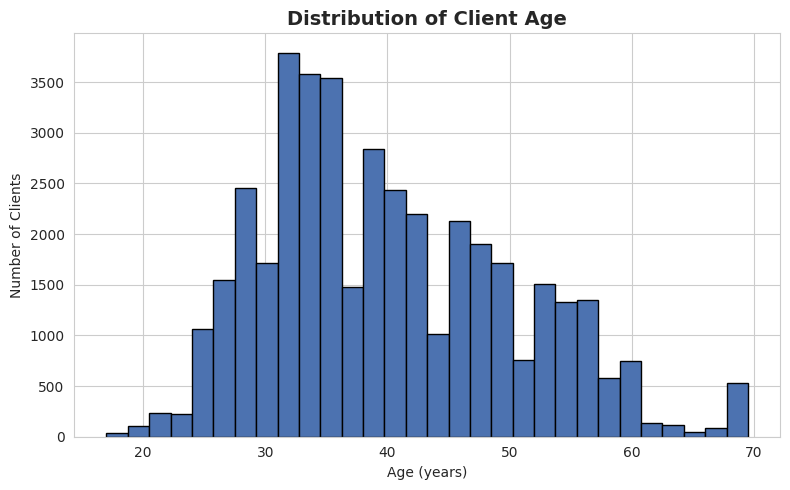

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=30, color="#4C72B0", edgecolor="black")
plt.title("Distribution of Client Age", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("../images/histogram.png")
plt.show()

### 5.2 Bar Chart — Subscription Rate by Job

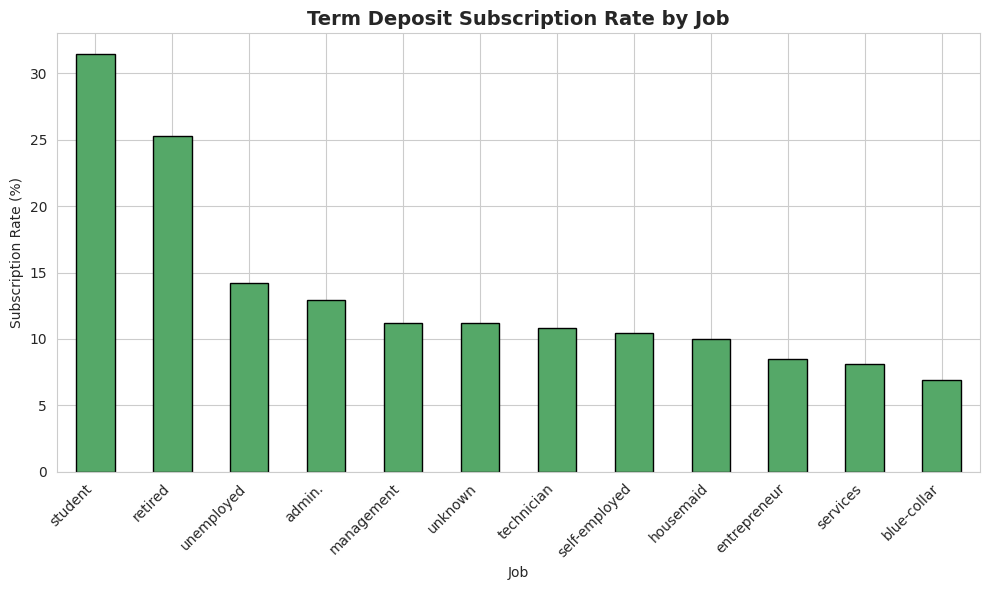

In [14]:
job_rate = (
    df.groupby("job")["y"]
    .apply(lambda x: (x == "yes").mean() * 100)
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
job_rate.plot(kind="bar", color="#55A868", edgecolor="black")
plt.title("Term Deposit Subscription Rate by Job", fontsize=14, fontweight="bold")
plt.xlabel("Job")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/barchart_job_subscription.png")
plt.show()

### 5.3 Count Plot — Subscription Outcome (y)

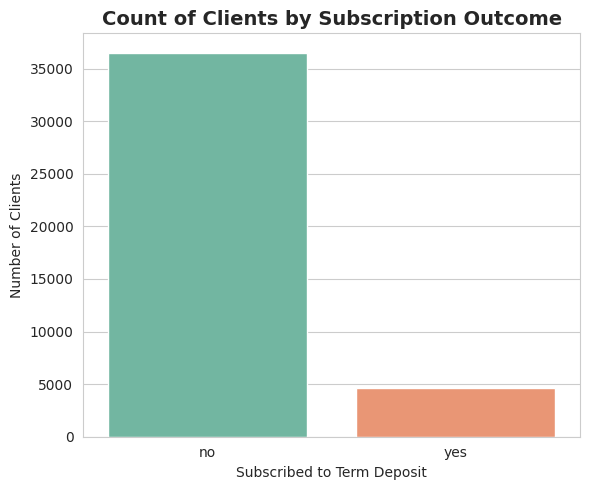

In [15]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="y", hue="y", palette="Set2", legend=False)
plt.title("Count of Clients by Subscription Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("../images/countplot_subscription.png")
plt.show()

### 5.4 Count Plot — Marital Status

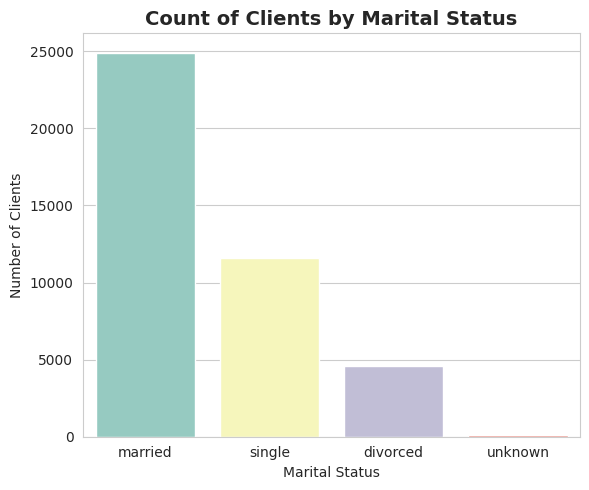

In [16]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="marital", hue="marital",
              order=df["marital"].value_counts().index,
              palette="Set3", legend=False)
plt.title("Count of Clients by Marital Status", fontsize=14, fontweight="bold")
plt.xlabel("Marital Status")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.savefig("../images/countplot_marital.png")
plt.show()

### 5.5 Box Plot — Age by Subscription Outcome

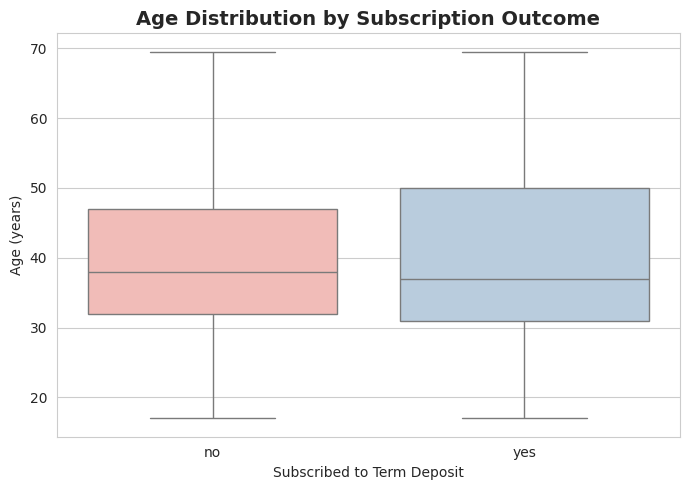

In [17]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="y", y="age", hue="y", palette="Pastel1", legend=False)
plt.title("Age Distribution by Subscription Outcome", fontsize=14, fontweight="bold")
plt.xlabel("Subscribed to Term Deposit")
plt.ylabel("Age (years)")
plt.tight_layout()
plt.savefig("../images/boxplot_age_subscription.png")
plt.show()

### 5.6 Box Plot — Call Duration (Cleaned)

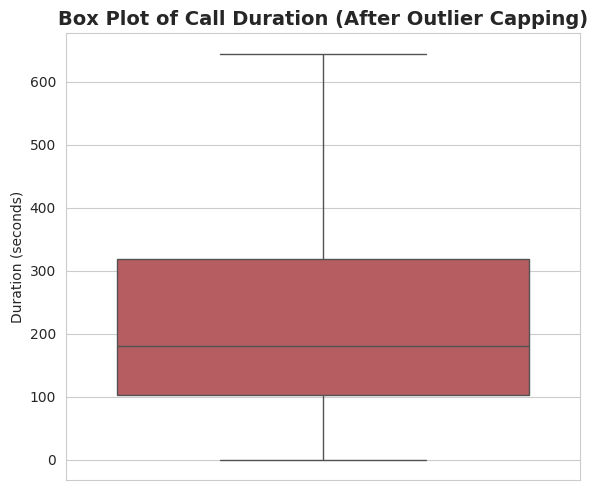

In [18]:
plt.figure(figsize=(6, 5))
sns.boxplot(y=df["duration"], color="#C44E52")
plt.title("Box Plot of Call Duration (After Outlier Capping)", fontsize=14, fontweight="bold")
plt.ylabel("Duration (seconds)")
plt.tight_layout()
plt.savefig("../images/boxplot.png")
plt.show()

### 5.7 Correlation Heatmap — Numeric Features

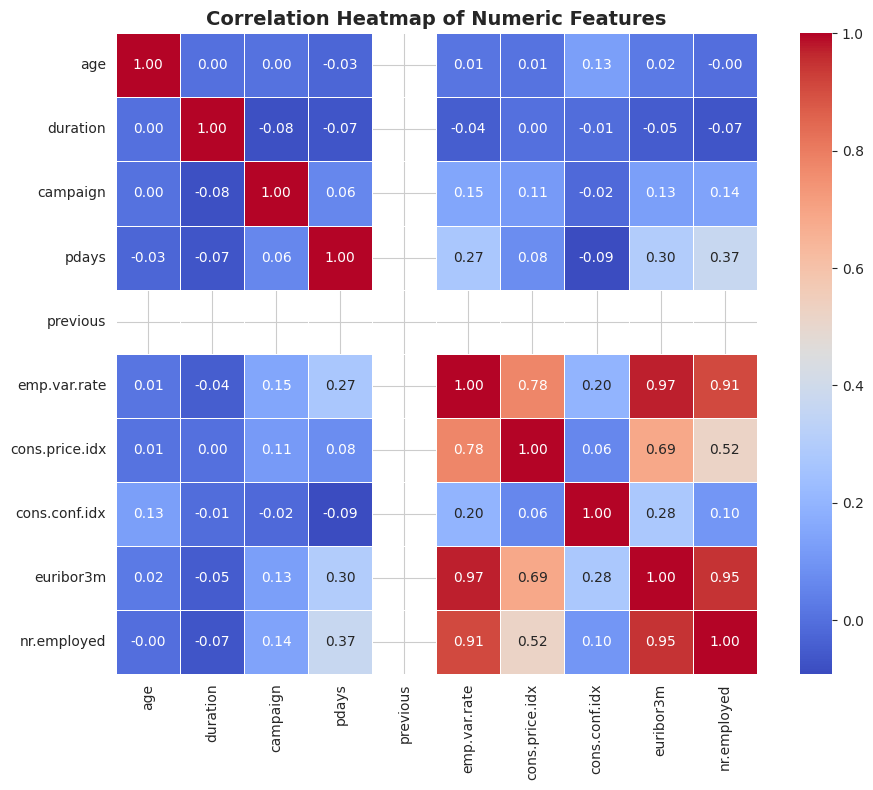

In [19]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap of Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/heatmap.png")
plt.show()

### 5.8 Pie Chart — Contact Communication Type

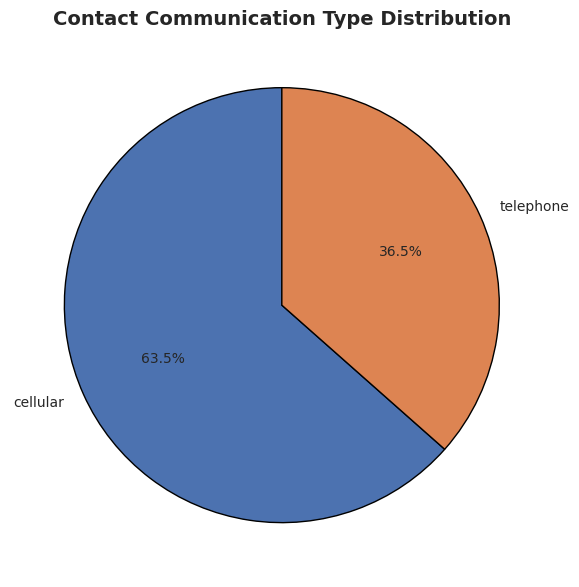

In [20]:
contact_counts = df["contact"].value_counts()
plt.figure(figsize=(6, 6))
plt.pie(contact_counts.values, labels=contact_counts.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452"], startangle=90,
        wedgeprops={"edgecolor": "black"})
plt.title("Contact Communication Type Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../images/piechart_contact.png")
plt.show()

## 6. Dashboard / Visual Report

A combined grid view of all charts for a quick, single-glance summary.

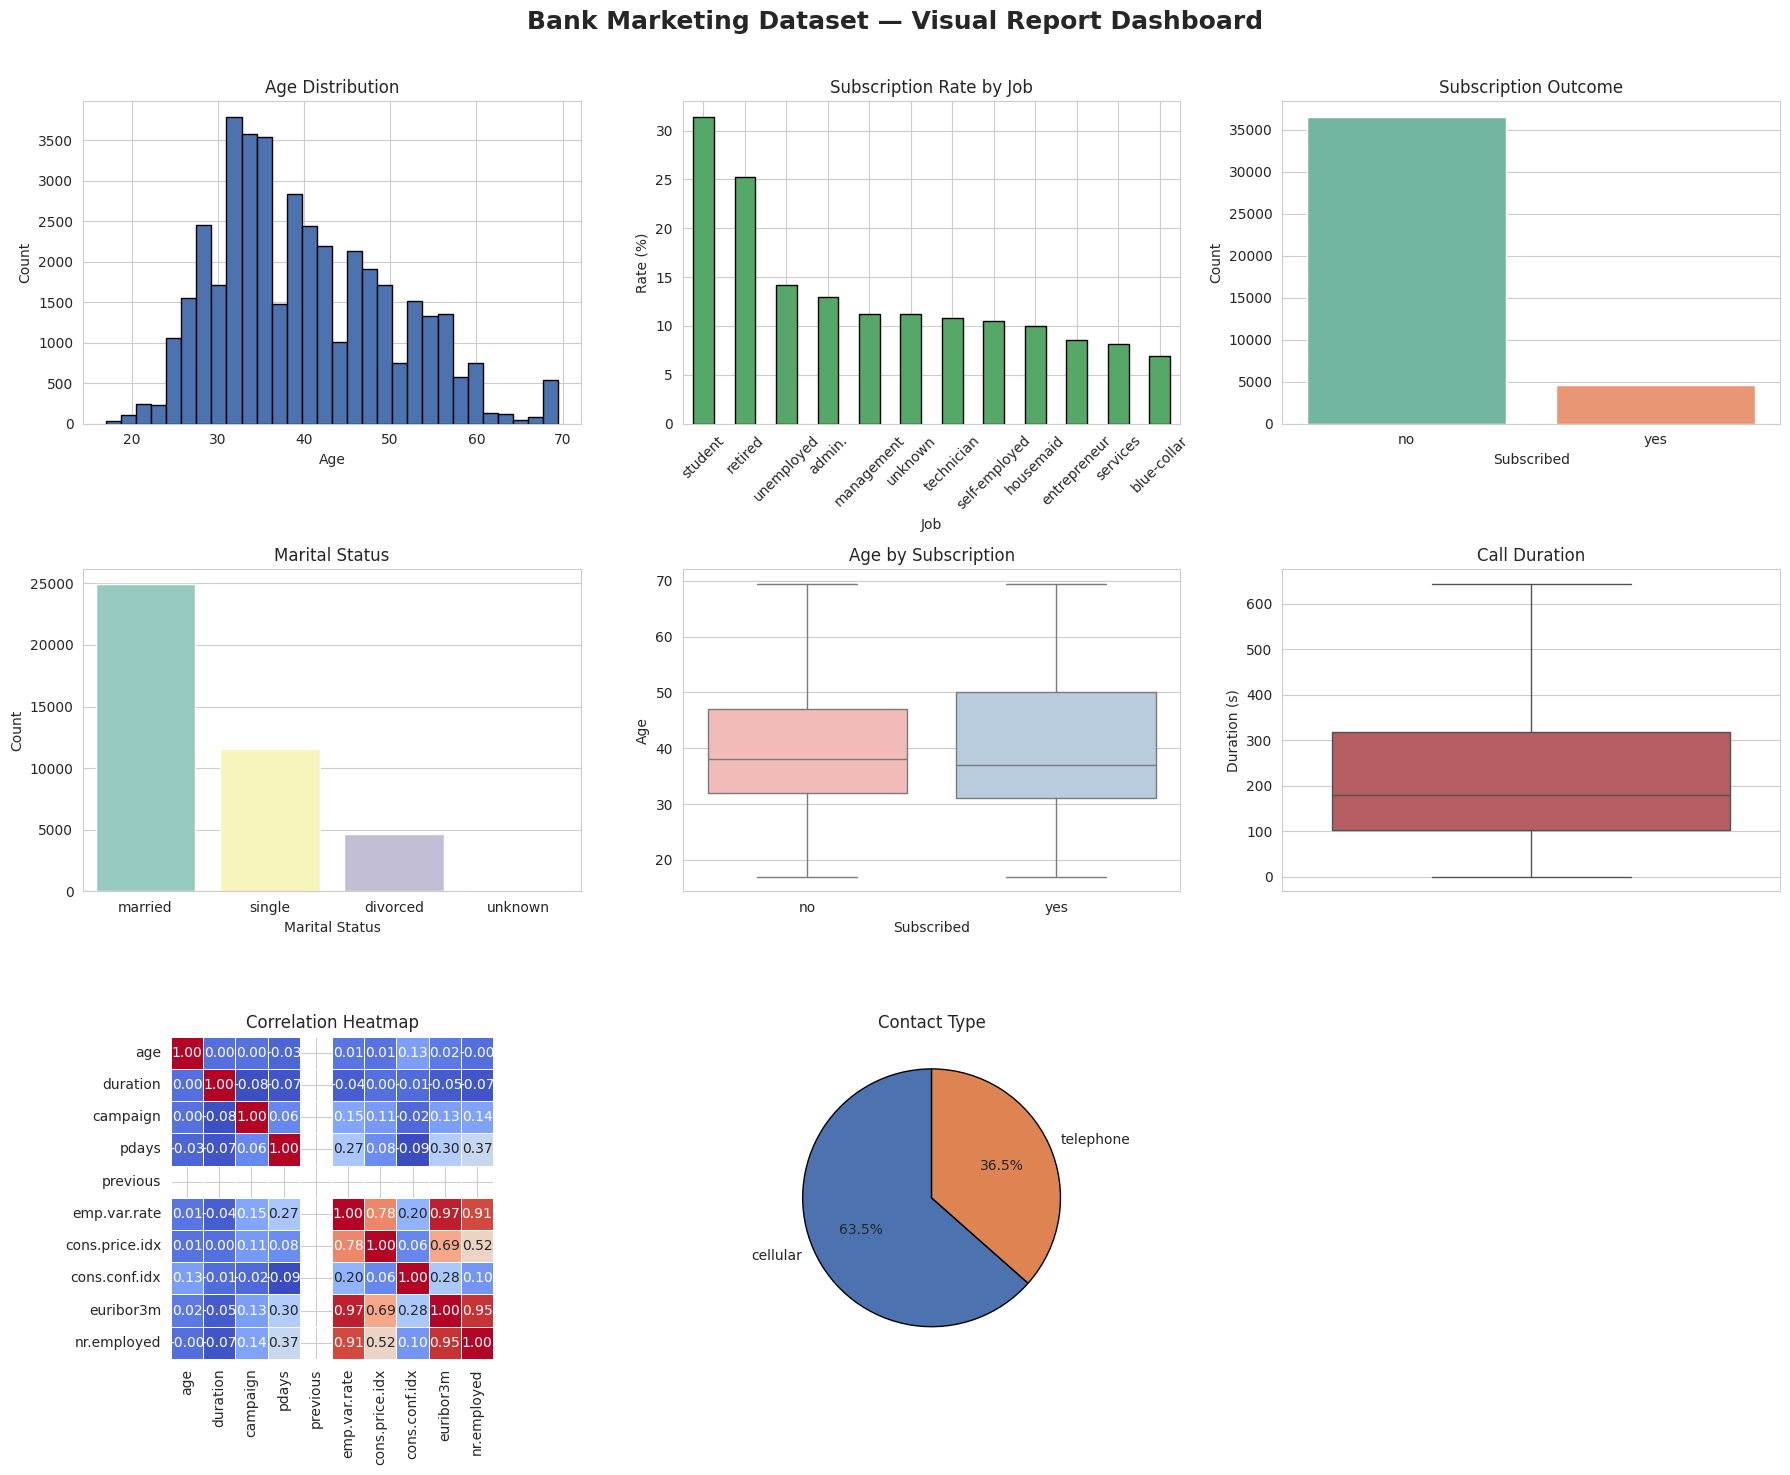

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle("Bank Marketing Dataset — Visual Report Dashboard", fontsize=18, fontweight="bold")

# Histogram
axes[0, 0].hist(df["age"], bins=30, color="#4C72B0", edgecolor="black")
axes[0, 0].set_title("Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Count")

# Bar chart
job_rate.plot(kind="bar", ax=axes[0, 1], color="#55A868", edgecolor="black")
axes[0, 1].set_title("Subscription Rate by Job")
axes[0, 1].set_xlabel("Job")
axes[0, 1].set_ylabel("Rate (%)")
axes[0, 1].tick_params(axis="x", rotation=45)

# Count plot y
sns.countplot(data=df, x="y", hue="y", palette="Set2", legend=False, ax=axes[0, 2])
axes[0, 2].set_title("Subscription Outcome")
axes[0, 2].set_xlabel("Subscribed")
axes[0, 2].set_ylabel("Count")

# Count plot marital
sns.countplot(data=df, x="marital", hue="marital",
              order=df["marital"].value_counts().index,
              palette="Set3", legend=False, ax=axes[1, 0])
axes[1, 0].set_title("Marital Status")
axes[1, 0].set_xlabel("Marital Status")
axes[1, 0].set_ylabel("Count")

# Box plot age by y
sns.boxplot(data=df, x="y", y="age", hue="y", palette="Pastel1", legend=False, ax=axes[1, 1])
axes[1, 1].set_title("Age by Subscription")
axes[1, 1].set_xlabel("Subscribed")
axes[1, 1].set_ylabel("Age")

# Box plot duration
sns.boxplot(y=df["duration"], color="#C44E52", ax=axes[1, 2])
axes[1, 2].set_title("Call Duration")
axes[1, 2].set_ylabel("Duration (s)")

# Heatmap
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, square=True, ax=axes[2, 0], cbar=False)
axes[2, 0].set_title("Correlation Heatmap")

# Pie chart
axes[2, 1].pie(contact_counts.values, labels=contact_counts.index, autopct="%1.1f%%",
               colors=["#4C72B0", "#DD8452"], startangle=90,
               wedgeprops={"edgecolor": "black"})
axes[2, 1].set_title("Contact Type")

# Hide the unused 9th subplot
axes[2, 2].axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("../images/dashboard_report.png")
plt.show()

## 7. Key Findings

Based only on the visualizations above:

1. **Age distribution** is right-skewed and concentrated between 30–50
   years, with fewer clients at the younger and older ends.
2. **Subscription rate by job** varies noticeably — students and retired
   clients show a higher term-deposit subscription rate than blue-collar
   or services workers.
3. **Overall subscription outcome** is heavily imbalanced: the large
   majority of clients did **not** subscribe to a term deposit.
4. **Marital status** shows most clients are married, followed by
   single, with divorced clients being the smallest group.
5. **Age vs. subscription**: clients who subscribed show a slightly
   wider age spread, including more older clients, compared to those
   who did not subscribe.
6. **Call duration** is strongly right-skewed even after capping,
   indicating most calls are short with a smaller number of longer calls.
7. **Correlation heatmap** shows `euribor3m`, `emp.var.rate`, and
   `nr.employed` are strongly positively correlated with each other,
   reflecting shared macroeconomic movement, while `duration` shows
   little linear correlation with other numeric features.
8. **Contact type**: cellular contact was used far more frequently than
   telephone, suggesting a shift in the bank's preferred communication
   channel.